## Network Builder - Parts 1 and 2
### Skill-Based Occupational Network Construction
This notebook cleans ESCO occupation-skill data, builds the occupation-skill matrix, computes Jaccard similarity, and constructs the occupational network.

## 1. Import Libraries

We begin by importing the main libraries used for data manipulation, similarity computation, network construction, and visualization.

In [35]:
import pandas as pd
import numpy as np
import itertools
from collections import defaultdict

import networkx as nx
from sklearn.metrics import pairwise_distances

## 2. Load Data

We load the ESCO occupation-skill dataset, which contains the relationships between occupations and the skills associated with them.

In [36]:
df = pd.read_csv("occupationSkillRelations_en.csv")
df.head()

,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...
3,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...,coordinate with creative departments
4,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...,adapt to artists' creative demands


In [37]:
df.columns.tolist()

['occupationUri',
 'occupationLabel',
 'relationType',
 'skillType',
 'skillUri',
 'skillLabel']

In [38]:
df.shape

(126051, 6)

## 3. Missing Values Check

Before constructing the network, we check whether the relevant variables contain missing values.

In [39]:
(df.isnull().sum() / len(df)) * 100

occupationUri      0.000000
occupationLabel    0.000000
relationType       0.000000
skillType          0.046806
skillUri           0.000000
skillLabel         0.000000
dtype: float64

In [40]:
df[['occupationLabel', 'skillLabel']].isnull().sum()

occupationLabel    0
skillLabel         0
dtype: int64

## 4. Data Cleaning and Preparation

We clean the dataset by keeping only the relevant variables (occupation and skills) and removing duplicate entries. This ensures that each occupation-skill relationship is represented only once before constructing the network.

In [41]:
df_clean = df[['occupationLabel', 'skillLabel']].drop_duplicates()
df_clean.head()

,occupationLabel,skillLabel
0,technical director,theatre techniques
1,technical director,organise rehearsals
2,technical director,write risk assessment on performing arts produ...
3,technical director,coordinate with creative departments
4,technical director,adapt to artists' creative demands


In [42]:
df_clean.shape

(126051, 2)

## 5. Occupation-Skill Matrix Construction

We construct a binary matrix where rows represent occupations and columns represent skills. A value of 1 indicates that an occupation requires a given skill.

In [43]:
matrix = pd.crosstab(df_clean['occupationLabel'], df_clean['skillLabel'])
matrix.iloc[:5, :5]

skillLabel,3D body scanning technologies,3D lighting,3D modelling,3D printing process,3D texturing
occupationLabel,,,,,
3D animator,0,1,0,0,1
3D modeller,0,1,0,1,1
3D printing technician,0,0,1,1,0
ATM repair technician,0,0,0,0,0
EU funds manager,0,0,0,0,0


In [44]:
matrix.shape

(3039, 13475)

## 6. Jaccard Similarity Computation

We compute similarity between occupations using the Jaccard index. This measure captures the proportion of shared skills between two occupations relative to the total number of skills they possess.

Higher similarity implies that two occupations require similar skill sets and therefore represent more feasible transitions.

In [45]:
# Convert matrix to binary (True/False)
binary_matrix = matrix.astype(bool)

# Convert to numpy array
binary_array = binary_matrix.to_numpy()

# Compute Jaccard distance
jaccard_dist = pairwise_distances(binary_array, metric='jaccard')

# Convert distance to similarity
jaccard_sim = 1 - jaccard_dist

# Check result
print(jaccard_sim.shape)

(3039, 3039)


## 7. Threshold Sensitivity Analysis

To validate the network construction, we analyze how different similarity thresholds affect the structure of the occupational network. Lower thresholds produce denser networks, while higher thresholds retain only stronger and more meaningful connections.

This analysis helps justify the choice of the threshold used in the main network.

In [47]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for tau in thresholds:
    adj_tau = (jaccard_sim > tau).astype(int)
    np.fill_diagonal(adj_tau, 0)

    G_tau = nx.from_numpy_array(adj_tau)

    n_edges = G_tau.number_of_edges()
    density = nx.density(G_tau)
    n_components = nx.number_connected_components(G_tau)
    largest_cc = max(nx.connected_components(G_tau), key=len)
    largest_cc_size = len(largest_cc)

    results.append({
        "threshold": tau,
        "edges": n_edges,
        "density": density,
        "n_components": n_components,
        "largest_component_size": largest_cc_size
    })

results_df = pd.DataFrame(results)
results_df

,threshold,edges,density,n_components,largest_component_size
0,0.1,66870,0.014486,50,2977
1,0.2,28813,0.006242,445,1751
2,0.3,14103,0.003055,1025,416
3,0.4,8635,0.001871,1627,84
4,0.5,6412,0.001389,2044,44


## 8. Threshold Sensitivity Plot

We visualize how the size of the largest connected component changes as the similarity threshold increases.

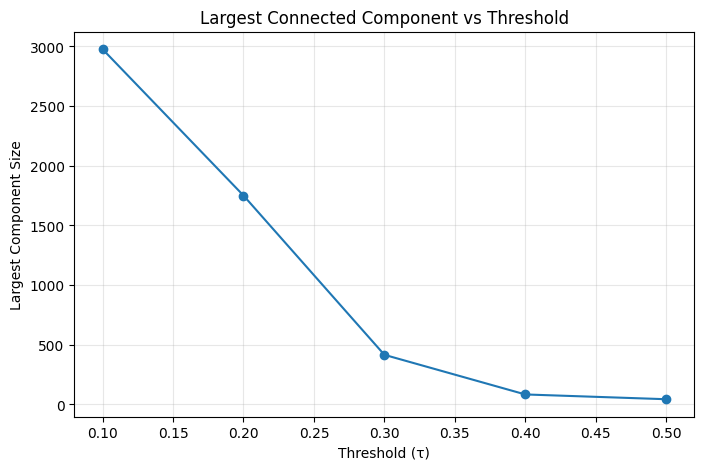

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["largest_component_size"], marker="o")
plt.title("Largest Connected Component vs Threshold")
plt.xlabel("Threshold (τ)")
plt.ylabel("Largest Component Size")
plt.grid(True, alpha=0.3)
plt.show()


The threshold sensitivity analysis shows that lower thresholds produce highly connected networks, while higher thresholds lead to increasingly fragmented structures.

At higher thresholds (e.g., τ = 0.3), the network becomes overly sparse, with the largest connected component including only a small fraction of occupations. This indicates that the similarity criterion is too restrictive, eliminating many plausible connections between occupations and limiting the ability to capture meaningful transition pathways.

As the threshold is reduced, connectivity increases. At τ = 0.15, the network achieves a high level of integration, with the majority of occupations belonging to a single large connected component. This suggests that the threshold is sufficiently permissive to capture relevant skill overlaps while maintaining a meaningful structure.

Therefore, we select **τ = 0.15** as a balance between avoiding excessive fragmentation and preserving a realistic representation of occupational similarity. This choice ensures that the resulting network captures feasible transitions across a broad range of occupations while still reflecting variation in connectivity.

## 9. Network Construction

We construct a network where nodes represent occupations and edges connect occupations with similarity above a given threshold τ. This allows us to focus on meaningful transitions between occupations.

In [ ]:
# Set threshold
threshold = 0.15
occ_labels = matrix.index.tolist()

# Build weighted graph with occupation labels as node names
G = nx.Graph()
G.add_nodes_from(occ_labels)

rows, cols = np.where(jaccard_sim > threshold)
for r, c in zip(rows, cols):
    if r < c:  # avoid duplicates and self-loops
        G.add_edge(occ_labels[r], occ_labels[c], weight=jaccard_sim[r, c])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

## Summary

In this section, we cleaned the ESCO data, constructed the occupation-skill matrix, computed occupational similarity using the Jaccard index, built the occupational network, and justified the selection of the threshold used in the main analysis.

In [49]:
# Export threshold sensitivity results
#results_df.to_csv("threshold_sensitivity_results.csv", index=False)

# Export Jaccard similarity matrix
#pd.DataFrame(jaccard_sim, index=matrix.index, columns=matrix.index).to_csv("jaccard_similarity_matrix.csv")

# Export network edges with weights
#nx.write_graphml(G, "occupational_network_tau03.graphml")

## 10. Network Overview


We compute basic descriptive statistics of the occupational network. Specifically, we measure the number of nodes (occupations), the number of edges (similarity-based connections), network density (the proportion of possible connections that are realized), and the average degree (average number of connections per occupation).

In [50]:
n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)

degrees = dict(G.degree())
avg_degree = sum(degrees.values()) / n_nodes

print("=== Network Overview ===")
print(f"Number of nodes: {n_nodes}")
print(f"Number of edges: {n_edges}")
print(f"Density: {density:.4f}")
print(f"Average degree: {avg_degree:.2f}")

=== Network Overview ===
Number of nodes: 3039
Number of edges: 41762
Density: 0.0090
Average degree: 27.48


The occupational network consists of 3,039 nodes and 41,762 edges, with a density of 0.0090. While the network remains relatively sparse compared to a fully connected graph, this higher density indicates a greater degree of interconnectedness across occupations than previously observed. A larger share of occupation pairs exhibit meaningful skill similarity, suggesting more potential pathways for transitions.

The average degree is 27.48, meaning that, on average, each occupation is connected to approximately 27 others. This suggests that many occupations have a broader set of similar alternatives, reflecting more widespread overlap in skill requirements. Compared to a more sparse structure, this indicates increased potential for occupational mobility, as workers may have access to a wider range of feasible transitions.

## 11. Connectivity Analysis


We analyze the structure of the network by identifying connected components—groups of occupations that are reachable from one another through paths of similarity links. We also compute the size of the largest connected component and its share of total nodes.

In [51]:
n_components = nx.number_connected_components(G)
components = list(nx.connected_components(G))

largest_cc = max(components, key=len)
largest_cc_size = len(largest_cc)
largest_cc_share = largest_cc_size / n_nodes

print("\n=== Connectivity Analysis ===")
print(f"Number of connected components: {n_components}")
print(f"Largest component size: {largest_cc_size}")
print(f"Share of nodes in largest component: {largest_cc_share:.4f}")


=== Connectivity Analysis ===
Number of connected components: 189
Largest component size: 2771
Share of nodes in largest component: 0.9118


The network contains 189 connected components, indicating a lower level of fragmentation. The largest connected component includes 2,771 occupations, representing approximately 91.18% of the network. This suggests that the occupational space is highly integrated, with the vast majority of occupations belonging to a single interconnected structure. As a result, transitions between occupations are generally feasible through direct or indirect paths within this large component.

The remaining smaller components likely correspond to highly specialized or niche occupations that are less connected to the broader labor market. Overall, the structure indicates a well-connected occupational network, supporting broader potential for labor mobility across most occupations.

## 12. Degree Distribution 

We examine how connections are distributed across occupations by plotting the degree distribution. This shows how many occupations have few versus many connections.

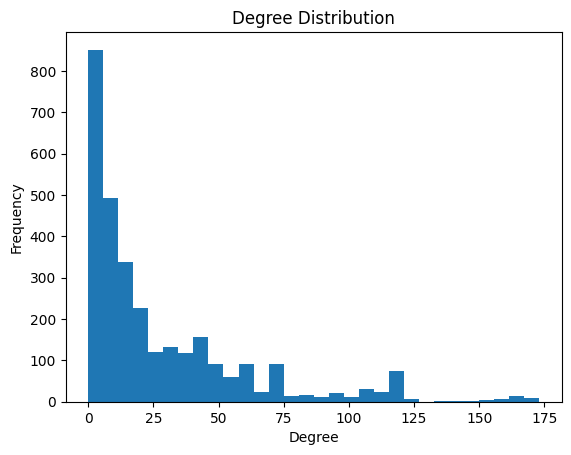

In [52]:
degree_values = list(degrees.values())

plt.figure()
plt.hist(degree_values, bins=30)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.show()

The degree distribution is strongly right-skewed, indicating that most occupations have relatively few connections, while a small number of occupations have a large number of links.

This suggests the presence of hub occupations with broadly transferable skills, which are connected to many other roles and may facilitate transitions across different parts of the network. In contrast, the majority of occupations remain more specialized, with fewer direct connections.

Despite the overall high level of connectivity in the network, this uneven structure highlights heterogeneity in transition opportunities, where some occupations are significantly more central and flexible than others within the labor market.

## 10. Network Visualization

To make the network interpretable, we visualize a sample of 100 nodes from the largest connected component. Node size reflects degree (number of connections), and only the most connected nodes are labeled to reduce visual clutter.

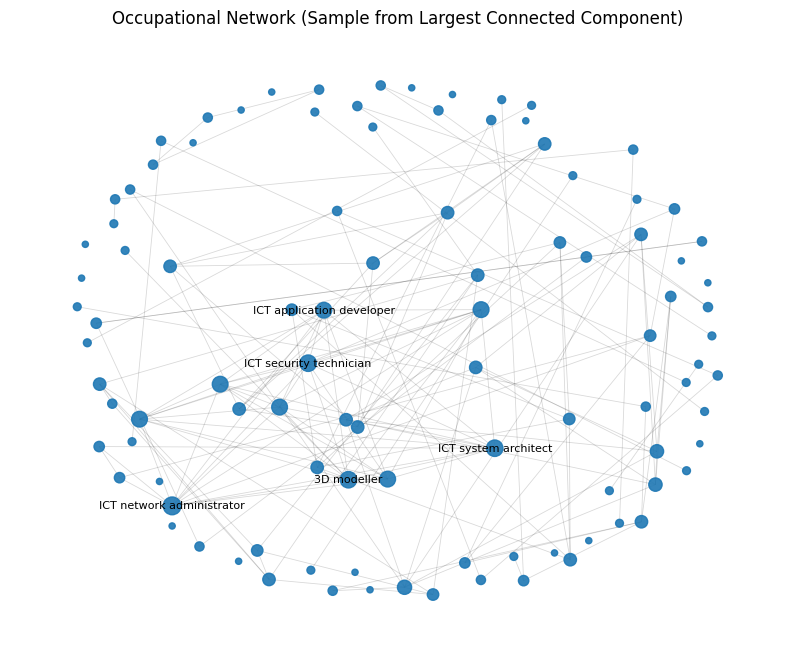

In [68]:
import networkx as nx

# Extract largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

# Take a sample of 100 nodes 
sample_nodes = list(G_lcc.nodes())[:100]
G_vis = G_lcc.subgraph(sample_nodes).copy()

#  Node sizes based on degree
degrees = dict(G_vis.degree())
node_sizes = [degrees[n] * 12 + 20 for n in G_vis.nodes()]

# 4. Label top 5 nodes
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
labels = {n: n for n in top_nodes}

# 5. Layout
pos = nx.spring_layout(G_vis, seed=42, k=0.9)

# 6. Plot
plt.figure(figsize=(10, 8))

nx.draw_networkx_edges(G_vis, pos, alpha=0.15, width=0.6)
nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

plt.title("Occupational Network (Sample from Largest Connected Component)")
plt.axis("off")
plt.show()

The visualization reveals a highly interconnected structure within the occupational network, consistent with the presence of a large connected component. Most occupations are linked either directly or indirectly, forming a cohesive network rather than isolated clusters.

Within this structure, areas of higher density can still be observed, indicating groups of occupations that share similar skill requirements and are more tightly connected. Larger nodes, representing occupations with higher degree, tend to occupy more central positions and may act as key connectors, facilitating transitions across different parts of the network.

At the same time, the presence of peripheral and less connected nodes suggests that some occupations remain more specialized, with fewer direct connections. Overall, the visualization highlights a well-connected but heterogeneous labor market, where mobility is broadly feasible but unevenly distributed across occupations.